In [1]:
import numpy as np, matplotlib.pyplot as plt, scipy as sp
from dataclasses import dataclass
from scipy.special import hermite
from math import factorial
import torch

hbar = sp.constants.hbar
pi = sp.constants.pi


def ho_wf(n, x, m=1, w=1, hbar=hbar):
    """Calculates the nth HO eigenstate."""
    alpha = np.sqrt(m * w / hbar)
    # Hermite polynomial H_n(y)
    H = hermite(n)
    # Normalization constant
    N = 1.0 / np.sqrt(2**n * factorial(n)) * np.sqrt(alpha / np.sqrt(np.pi))
    return (N * H(alpha * x) * np.exp(-(alpha * x)**2 / 2)).astype(np.complex64)

def not_eigenstate(x, dx):
    wf = np.exp(-1*np.abs(x)).astype(np.complex128)
    wf *= (np.sum(np.abs(wf)**2*dx))**(-1/2)
    return wf
def not_eigenstate_3D(x,y,z, dx):
    wf = (np.exp(-1*np.abs(x))*np.exp(-1*np.abs(y))*np.exp(-1*np.abs(z))).astype(np.complex128)
    wf *= (np.sum(np.abs(wf)**2*dx**3))**(-1/2)
    print(np.sum(np.abs(wf)**2)*dx**3)
    # NOTE that we cannot take the 1D function and multiply three of them to generate the 3D wavefunction.
    # This is because we end up passing in the coordinate grid from np.meshgrid, which normalizes an array of dim NxNxN rather than N.as_integer_ratio
    # So, it's better to do this separately.

    return wf

In [7]:
# Define simulation parameters

@dataclass
class BEC:

    m = 1.9e-25 #kg
    omega = 2 * pi * 40 #Hz
    gamma = 1
    particles = 10**7
    a_00 = 2e-9
    a_02_vals = (-3e-21, -4e-21)
    a_02 = -4e-21
    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale

    g_0 = 4*pi*(hbar**2)*a_00/m
    g_2 = 6*np.sqrt(5)*pi * hbar**2 * a_02/m

    #sim params

    up = 25e-6 # microns, upper bound of one dim (+L/2 coordinate for L^3 box)
    N = 100
    sigma = 10e-6 #microns; Gaussian ansatz parameter
    spacing = 2*up/N

    k_cutoff = 10**6 #pi/spacing #m^-1
    print(k_cutoff)
    cutoff = True

    vol = (2*up)**3 #Approximate volume based on parameters
    n_0 = particles #particles/vol #Approximate particle density (helps to normalize wf to O(1))

    ev_time = 50e-3 #ms
    time_steps = 100
    


# Define wavefunction: Gaussian ansatz TODO

def psi(x,y,z,sigma, N, spacing):

    p = np.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)

    norm = np.sum(np.absolute(p)**2 * spacing**3) # Approximate the integral of the ansatz over the region

    p *= np.sqrt(N/norm) # Ensure wavefunction integrates to particle number   

    return p

def initialize():

    up = BEC.up
    N = BEC.N
    spacing = BEC.spacing
    sigma = BEC.sigma
    n_0 = BEC.n_0
    
    # Define coordinate grid

    x, y, z = np.linspace(-up,up,N, endpoint=False), np.linspace(-up,up,N, endpoint=False), np.linspace(-up,up,N, endpoint=False)
    X,Y,Z = np.meshgrid(x,y,z, indexing="ij")

    dx = x[1]-x[0]

    wf = psi(X,Y,Z,sigma, BEC.particles, dx)

    print(np.mean(wf), np.max(wf), np.sum(np.absolute(wf)**2)*(dx)**3)

    #Nondimensionalization

    unitless_wf = wf * BEC.l**(3/2)/np.sqrt(n_0)

    print(np.mean(unitless_wf), np.max(unitless_wf),np.sum(np.absolute(unitless_wf)**2)*(dx/BEC.l)**3)

    #uX stands for unitless X coordinates
    uX,uY,uZ = X/BEC.l, Y/BEC.l, Z/BEC.l

    # Define momentum grid
    kx, ky, kz = 2*pi*np.fft.fftfreq(N, d=dx/BEC.l), 2*pi*np.fft.fftfreq(N, d=dx/BEC.l), 2*pi*np.fft.fftfreq(N, d=dx/BEC.l) # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    KX, KY, KZ = np.meshgrid(kx,ky,kz, indexing="ij")

    #Define unitless G0, G2

    G0 = BEC.g_0 *n_0 / (hbar*BEC.omega*BEC.l**3)
    G2 = BEC.g_2 *n_0 / (hbar * BEC.omega * BEC.l**5)

    return unitless_wf, (uX,uY,uZ), (KX, KY, KZ), (G0, G2)


# Define operators

def trap_potential(x,y,z, gamma):
    return (-1j/2)*(x**2+y**2+gamma**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def G0_term(psi, G0):
    return -1j * G0 * np.absolute(psi)**2 

def laplacian(kx,ky,kz):
    return (1j/2) * (kx**2+ky**2+kz**2) # laplacian already in momentum space

def quadrupole(psi, kx, ky, kz, G2, cutoff):

    if cutoff == True:

        K2 = kx**2+ky**2+kz**2

        mask = (K2 < (BEC.k_cutoff*BEC.l)**2) # This is an array of 1's and 0's (T/F's) corresponding to where the condition holds true

        mask1 = (kx**2+ky**2 < (BEC.k_cutoff*BEC.l)**2)
        mask2 = (kz < BEC.k_cutoff*BEC.l)

        op = np.fft.fftn(np.absolute(psi)**2) * (-1*kz**2 + (1/3)*(kx**2+ky**2+kz**2)) # Quadrupole op in fourier domain
        op *= mask

        #print(op.size-np.count_nonzero(op))

        #op *= mask1 # Apply the TF array to set operator to zero for large k values (ie. momentum cutoff)
        #op *= mask2

        op = -1j * G2 * np.fft.ifftn(op) # Bring back to position space so that it can be applied to psi

        #print(np.mean(op), np.max(op))

        return op

    elif cutoff == False:
    
        op =  np.fft.fftn(np.absolute(psi)**2) * (-1*kz**2 + (1/3)*(kx**2+ky**2+kz**2))
        return -1j * G2 *  np.fft.ifftn(op)

    else:
        print("cutoff must be True/False")

def evolution():

    ev_time = BEC.ev_time
    time_steps = BEC.time_steps

    dt = ev_time/time_steps
    dt = dt/BEC.tau # unitless time step

    wf, (uX,uY,uZ), (KX, KY, KZ), (G0, G2) = initialize()

    for i in range(time_steps):

        # Apply position-basis operators for interval dt/2

        wf *= np.exp((trap_potential(uX, uY, uZ, BEC.gamma) + G0_term(wf, G0) + quadrupole(wf, KX, KY, KZ, G2, cutoff=BEC.cutoff)) * (dt/2))

        # Apply momentum-basis operators for interval dt

        wf = np.fft.fftn(wf)

        wf *= np.exp((laplacian(KX, KY, KZ)) * dt)

        wf = np.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        #wf *= np.exp(quadrupole(wf, KX, KY, KZ, G2, cutoff=BEC.cutoff) * dt)

        wf *= np.exp((trap_potential(uX, uY, uZ, BEC.gamma) + G0_term(wf, G0) + quadrupole(wf, KX, KY, KZ, G2, cutoff=BEC.cutoff)) * (dt/2))

        if i % 5 == 0:
            print("Time Step: ",i)

    
    # Redimensionalize result

    redim_wf = wf* BEC.l**(-3/2) * np.sqrt(BEC.n_0)

    print(BEC.particles, np.sum(np.absolute(redim_wf)**2)*BEC.spacing**3)

    return redim_wf, wf
    
final_wf, wf = evolution()

#Integrate out z component

xy_particle_density = np.sum(np.absolute(final_wf)**2, axis=2) * BEC.spacing
unitless_density = np.sum(np.absolute(wf)**2, axis=2) * BEC.spacing/BEC.l

1000000
(5145856591.306752+0j) (42403746794.68888+0j) 9999999.999999996
(0.0029479472231325613+0j) (0.024292166988290585+0j) 1.0
Time Step:  0
Time Step:  5
Time Step:  10
Time Step:  15
Time Step:  20
Time Step:  25
Time Step:  30
Time Step:  35
Time Step:  40
Time Step:  45
Time Step:  50
Time Step:  55
Time Step:  60
Time Step:  65
Time Step:  70
Time Step:  75
Time Step:  80
Time Step:  85
Time Step:  90
Time Step:  95
10000000 10000000.000000132


In [40]:
a = np.array([1,2,3,4,5])

a * (a > 2)

array([0, 0, 3, 4, 5])

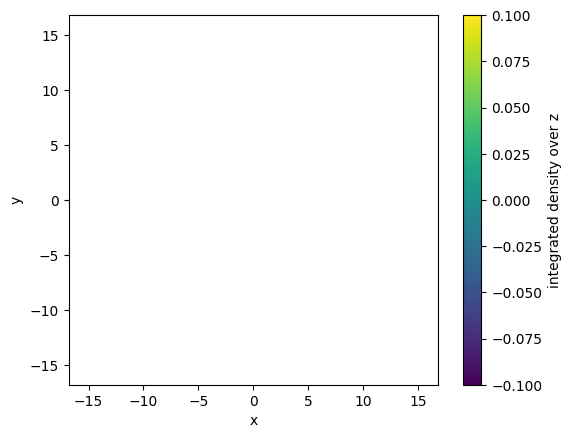

In [ ]:
xz_particle_density = np.sum(np.absolute(final_wf)**2, axis=1) * BEC.spacing
yz_particle_density = np.sum(np.absolute(final_wf)**2, axis=0) * BEC.spacing
dimensionless_bound = BEC.up/BEC.l
plt.figure()
plt.imshow(unitless_density, origin='lower', extent = [-dimensionless_bound, dimensionless_bound, -dimensionless_bound, dimensionless_bound])
plt.colorbar(label="integrated density  over z")
plt.xlabel("x")
plt.ylabel('y')
plt.show()

unitless time:  12.566370614359174
unitless distance: 8.0
dtau:  0.012566370614359173
Psi normalization: 1.0000000012675916
Final WF normalization 1.0000000012677426
L2 Error: 3.269852853862802e-08
Relative L2 Error: 3.269852851790384e-08


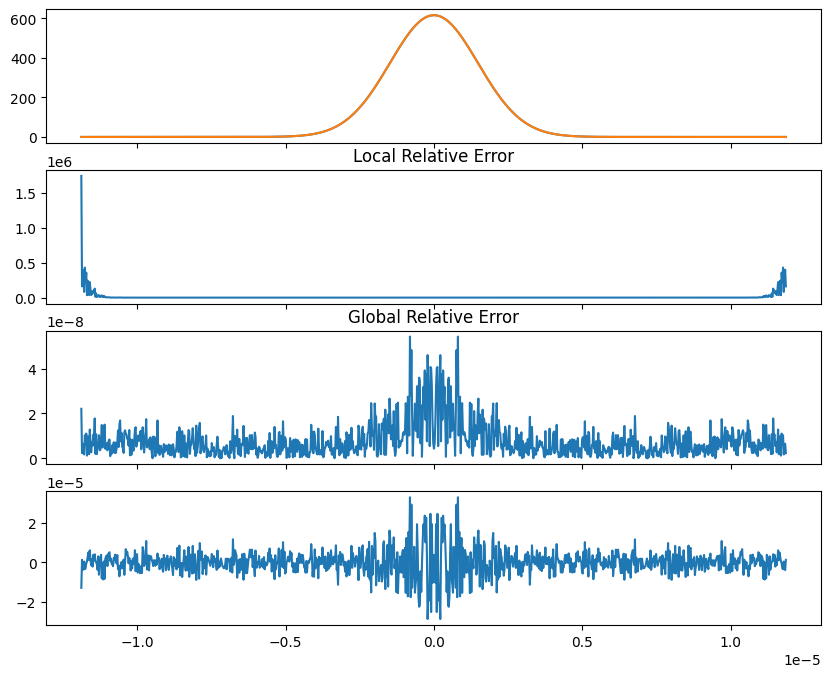

In [80]:
# Define simulation parameters

@dataclass
class HMO1D:

    m = 1.9e-25 #kg
    omega = 2 * pi * 40 #Hz

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale

    #sim params

    up = 8*l
    N = 1000

    ev_time = 5e-2 #s
    time_steps = 1000

    X = np.linspace(-up,up,N, endpoint=False)
    dx = X[1]-X[0]
    


# Define wavefunction: Gaussian ansatz TODO

def psi(x):
    m = HMO1D.m
    w = HMO1D.omega
    dx = HMO1D.dx
    n2 = ho_wf(0, x, m=m, w=w).astype(np.complex128)     
    n0 = ho_wf(0, x, m=m, w=w).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)
    wf3 = not_eigenstate(x, dx)
    return n2

def initialize():

    N = HMO1D.N
    X = HMO1D.X
    dx = HMO1D.dx
    l = HMO1D.l

    assert dx < l


    wf = psi(X)
    print("Psi normalization:", np.sum((np.absolute(wf)**2) * HMO1D.dx))

    #Nondimensionalization
    unitless_wf = wf * HMO1D.l**(1/2)

    #uX stands for unitless X coordinates
    uX = X/HMO1D.l

    # Define momentum grid
    KX = 2*pi*np.fft.fftfreq(N, d=dx/HMO1D.l) # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    return unitless_wf, uX, KX

# Define operators

def trap_potential(x):
    return (1/2)*(x**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def kinetic_energy(kx):
    return (1/2) * (kx**2) # KE already in momentum space

def evolution():

    ev_time = HMO1D.ev_time
    time_steps = HMO1D.time_steps

    print("unitless time: ", ev_time/HMO1D.tau)
    print("unitless distance:", HMO1D.up/HMO1D.l)

    dt = ev_time/time_steps
    dtau = dt/HMO1D.tau # unitless time step

    print("dtau: ",dtau)

    wf, uX, KX = initialize()

    ends = []

    for _ in range(time_steps):

        # Apply position-basis operators for interval dt/2

        wf *= np.exp(-1j *(trap_potential(uX)) * (dtau/2))

        # Apply momentum-basis operators for interval dt

        wf = np.fft.fft(wf)

        wf *= np.exp(-1j*(kinetic_energy(KX)) * dtau)

        wf = np.fft.ifft(wf)

        # Apply position-basis operators for interval dt/2

        wf *= np.exp(-1j*(trap_potential(uX)) * (dtau/2))

        ends.append(wf[-1])

        
    # Redimensionalize result

    redim_wf = wf* HMO1D.l**(-1/2)

    ends = np.array(ends)*HMO1D.l**(-1/2)

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*HMO1D.dx)

    return redim_wf, wf, ends
    
final_wf, wf, ends = evolution()
X = HMO1D.X
init_psi = psi(X)

ev_time = HMO1D.ev_time
time_steps = HMO1D.time_steps
times = np.linspace(0, ev_time, time_steps)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)


rel_error = np.abs(np.abs(init_psi) - np.abs(final_wf))/psi(X)
rel_max_error = np.abs(np.abs(init_psi) - np.abs(final_wf))/np.max(psi(X))

ax1.plot(X, final_wf)
ax1.plot(X, init_psi)
ax2.plot(X, rel_error)
ax2.set_title(("Local Relative Error"))
ax3.plot(X, rel_max_error)
ax3.set_title("Global Relative Error")
ax4.plot(X, final_wf-init_psi)

# L2 norm error (more standard)
L2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * HMO1D.dx)
print("L2 Error:", L2_error)

# Or relative L2 error
rel_L2_error = L2_error / np.sqrt(np.sum(np.abs(init_psi)**2) * HMO1D.dx)
print("Relative L2 Error:", rel_L2_error)

1.426024500127321e-06 (8.867527372113937e-12+0j) 1.4260170213714807e-06
616.1576564615898 (616.1576538085938+0j) 0.025473161680157452


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


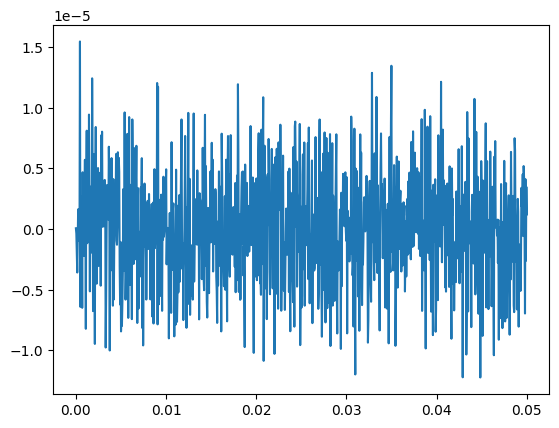

In [83]:
plt.plot(times, ends-init_psi[-1])
print(np.abs(final_wf[-1]), init_psi[-1], np.abs(final_wf[-1]-init_psi[-1]))
print(np.abs(final_wf[500]), init_psi[500], np.abs(final_wf[500]-init_psi[500]))

In [15]:
np.abs(final_wf[-1]), np.abs(init_psi[-1]), np.abs(final_wf[-50]), np.abs(init_psi[-50]), rel_error[-1], rel_error[1]

(np.float64(0.20027560578482448),
 np.float64(0.0832933709025383),
 np.float64(0.7113711460746713),
 np.float64(0.6895127892494202),
 np.complex128(1.4044603263705975+0j),
 np.complex128(1.4044603263770359+0j))

In [21]:
t = list(range(9))
t[:3]

[0, 1, 2]

unitless time:  12.566370614359174
unitless distance: 6.0
length scale 6.0
dt/time scale: 0.016755160819145565
length resolution 8.916462771083126e-08 1.4860771285138543e-06
1.0000000000000007
Psi normalization: 0.9999999855836272
0
100
200
300
400
500
600
700
Final WF normalization 0.9999999851857301
1.0000000000000007
Max Global Relative Error: 2.87849349108239e-05
Boundary error: 28149.0045185496
L2 Error: 2.1937218699739044e-05
Relative L2 Error: 2.1937219366726305e-05


/var/folders/s8/3dmczk5d0590sbm079fw8qkw0000gn/T/ipykernel_23096/3157488459.py:146: RuntimeWarning: divide by zero encountered in divide
  rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)


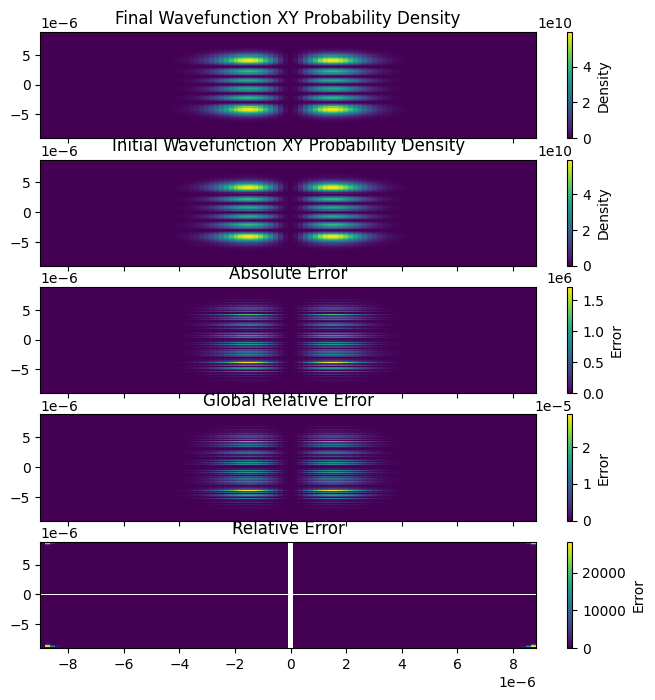

In [89]:
# Define simulation parameters

@dataclass
class HMO:

    m = 1.9e-25 #kg
    omega = 2 * pi * 40 #Hz

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale

    #sim params

    up = 6*l
    N = 100

    ev_time = 5e-2 #s
    time_steps = 750

    x = np.linspace(-up,up,N, endpoint=False)
    dx = x[1]-x[0]

    X, Y, Z = np.meshgrid(x,x,x, indexing='ij')
    
# Define wavefunction

def psi(x, y, z):
    m = HMO.m
    w = HMO.omega
    dx = HMO.dx
    hmo = ho_wf(n=1, x=x, m=m, w=w)*ho_wf(n=5, x=y, m=m,w=w)*ho_wf(n=0, x=z, m=m, w=w)
    ne = not_eigenstate_3D(x,y,z,dx)
    return hmo

def initialize():

    N = HMO.N
    X, Y, Z = HMO.X, HMO.Y, HMO.Z
    dx = HMO.dx
    l = HMO.l

    assert dx < l

    wf = psi(X, Y, Z)
    print("Psi normalization:", np.sum((np.absolute(wf)**2) * dx**3))

    #Nondimensionalization
    unitless_wf = wf * l**(3/2)

    #uX stands for unitless X coordinates
    uX, uY, uZ = X/l, Y/l, Z/l

    # Define momentum grid
    k = 2*pi*np.fft.fftfreq(N, d=dx/l)
    KX, KY, KZ = np.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    return unitless_wf, (uX, uY, uZ), (KX, KY, KZ)

# Define operators

def trap_potential(x,y,z):
    return (1/2)*(x**2+y**2+z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def kinetic_energy(kx, ky, kz):
    return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

def evolution():

    ev_time = HMO.ev_time
    time_steps = HMO.time_steps

    print("unitless time: ", ev_time/HMO.tau)
    print("unitless distance:", HMO.up/HMO.l)

    dt = ev_time/time_steps
    dtau = dt/HMO.tau # unitless time step

    print("length scale", HMO.up/HMO.l)
    print("dt/time scale:",dtau)

    print("length resolution", HMO.up/HMO.N, HMO.l)

    wf, (uX,uY,uZ), (KX,KY,KZ) = initialize()

    potential_step = np.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = np.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    for i in range(time_steps):

        # Apply position-basis operators for interval dt/2

        wf *= potential_step

        # Apply momentum-basis operators for interval dt

        wf = np.fft.fftn(wf)

        wf *= KE_step

        wf = np.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        wf *= potential_step

        if i % 100 == 0:
            print(i) 
    
    # Redimensionalize result

    redim_wf = wf* HMO.l**(-3/2)

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*HMO.dx**3)

    return redim_wf, wf
    
final_wf, wf = evolution()

x = HMO.x
p_X, p_Y = np.meshgrid(x, x, indexing='ij')

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

init_psi = psi(HMO.X, HMO.Y, HMO.Z)

xy_density = np.sum(np.abs(final_wf)**2 * HMO.dx, axis=2)
im1 = ax1.pcolormesh(p_X, p_Y, xy_density)
ax1.set_title("Final Wavefunction XY Probability Density")
fig.colorbar(im1, ax=ax1, label="Density")

initial_xy_density = np.sum(np.abs(init_psi)**2 * HMO.dx, axis=2)
im2 = ax2.pcolormesh(p_X, p_Y, initial_xy_density)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

diff = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))
im3 = ax3.pcolormesh(p_X, p_Y, diff)
ax3.set_title("Absolute Error")
fig.colorbar(im3, ax=ax3, label="Error")

global_rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(np.max(initial_xy_density))
im4 = ax4.pcolormesh(p_X, p_Y, global_rel_error)
ax4.set_title("Global Relative Error")
fig.colorbar(im4, ax=ax4, label="Error")

rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)
im5 = ax5.pcolormesh(p_X, p_Y, rel_error)
ax5.set_title("Relative Error")
fig.colorbar(im5, ax=ax5, label="Error")

print("Max Global Relative Error:", np.max(global_rel_error))
print("Boundary error:",rel_error[-1,-1])

# L2 norm error (more standard)
L2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * HMO.dx**3)
print("L2 Error:", L2_error)

slice = 50
sliced_L2_error = np.sqrt(np.sum((np.abs(final_wf[slice:-1*slice]) - np.abs(init_psi[slice:-1*slice]))**2) * HMO.dx**3)
print(f"(ONLY CONSIDER FOR STEADY STATE) Sliced L2 Error (First {slice} points):", sliced_L2_error)

# Or relative L2 error
rel_L2_error = L2_error / np.sqrt(np.sum(np.abs(init_psi)**2) * HMO.dx**3)
print("Relative L2 Error:", rel_L2_error)

time scale: 0.0039788735772973835
unitless time:  2.5132741228718345
unitless distance: 16.82281459038479
time resolution: 0.002513274122871835
space resolution: 0.262856477974763
Psi normalization: 100000.00000000006
Final WF normalization 100000.0000000301


'diff = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))\nim3 = ax3.pcolormesh(pX, pY, diff)\nax3.set_title("Absolute Error")\nfig.colorbar(im3, ax=ax3, label="Error")\n\nglobal_rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(np.max(initial_xy_density))\nim4 = ax4.pcolormesh(pX, pY, global_rel_error)\nax4.set_title("Global Relative Error")\nfig.colorbar(im4, ax=ax4, label="Error")\n\nrel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)\nim5 = ax5.pcolormesh(pX, pY, rel_error)\nax5.set_title("Relative Error")\nfig.colorbar(im5, ax=ax5, label="Error")\n\nprint("Max Global Relative Error:", np.max(global_rel_error))\nprint("Boundary error:",rel_error[-1,-1])\n\n# L2 norm error (more standard)\nL2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * GPE1.dx**3)\nprint("L2 Error:", L2_error)\n\nslice = 50\nsliced_L2_error = np.sqrt(np.sum((np.abs(final_wf[slice:-1*slice]) - np.abs(init_psi[slice:-1*slice]))*

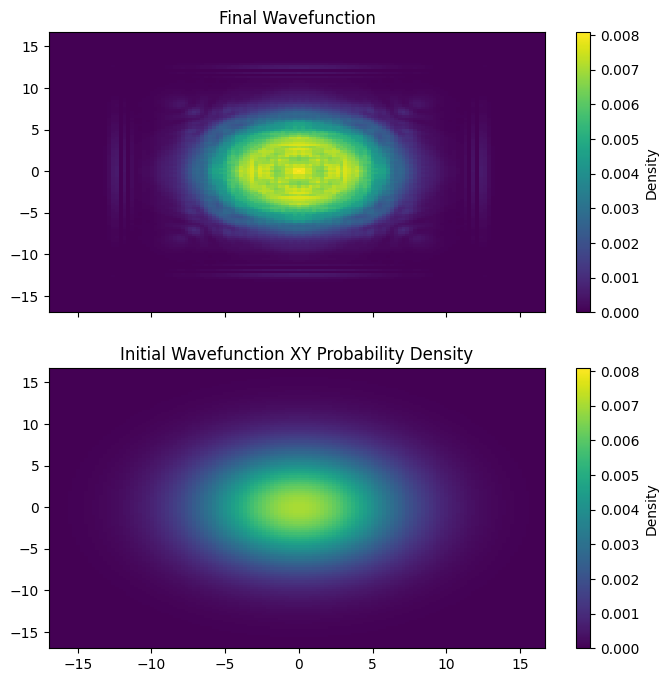

In [5]:
# Define simulation parameters

@dataclass
class GPE1:

    m = 1.9e-25 #kg
    omega = 2 * pi * 40 #Hz
    a0 = 2e-9 #m
    g0 = 4*pi*hbar**2*a0/m
    gamma = 10
    Np=1e5

    sigma = 10e-6

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale

    G0 = g0/(l**3*hbar*omega)

    #sim params

    up = 2.5*sigma
    N = 128

    ev_time = 10e-3 #s
    time_steps = 1000

    x = np.linspace(-up,up,N, endpoint=False)
    dx = x[1]-x[0]

    X, Y, Z = np.meshgrid(x,x,x, indexing='ij')
    

# Define wavefunction: Gaussian ansatz TODO

def psi(x, y, z):
    sigma, dx, Np = GPE1.sigma, GPE1.dx, GPE1.Np
    gaussian = np.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = np.sum(np.abs(gaussian)**2) * dx**3
    gaussian *= (Np/norm)**(1/2) 
    return gaussian

def initialize():

    N = GPE1.N
    X, Y, Z = GPE1.X, GPE1.Y, GPE1.Z
    dx = GPE1.dx
    l = GPE1.l

    assert dx < l

    wf = psi(X, Y, Z)
    print("Psi normalization:", np.sum((np.absolute(wf)**2) * dx**3))

    #Nondimensionalization
    unitless_wf = wf * l**(3/2)

    #uX stands for unitless X coordinates
    uX, uY, uZ = X/l, Y/l, Z/l

    # Define momentum grid
    k = 2*pi*np.fft.fftfreq(N, d=dx/l)
    KX, KY, KZ = np.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    return unitless_wf, (uX, uY, uZ), (KX, KY, KZ)

# Define operators

def trap_potential(x,y,z):
    gam = GPE1.gamma
    return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def g0_term(psi): # in position basis
    return GPE1.G0 * np.abs(psi)**2


def kinetic_energy(kx, ky, kz):
    return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

def evolution():

    ev_time = GPE1.ev_time
    time_steps = GPE1.time_steps

    dxu = GPE1.dx/GPE1.l
    
    dt = ev_time/time_steps
    dtau = dt/GPE1.tau # unitless time step

    print("time scale:", GPE1.tau)
    print("unitless time: ", ev_time/GPE1.tau)
    print("unitless distance:", GPE1.up/GPE1.l)
    print("time resolution:", dtau)
    print("space resolution:", dxu)

    wf, (uX,uY,uZ), (KX,KY,KZ) = initialize()

    uR2 = uX**2+uY**2+uZ**2

    potential_step = np.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = np.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    waist = []

    for _ in range(time_steps):

        # Apply position-basis operators for interval dt/2

        wf *= potential_step
        wf *= np.exp(-1j *(g0_term(wf)) * (dtau/2))

        # Apply momentum-basis operators for interval dt

        wf = np.fft.fftn(wf)

        wf *= KE_step

        wf = np.fft.ifftn(wf)


        # Apply position-basis operators for interval dt/2

        wf *= potential_step
        wf *= np.exp(-1j*(g0_term(wf)) * (dtau/2))

        waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3)
        
    waist = np.array(waist) * GPE1.l**2
    
    # Redimensionalize result

    redim_wf = wf* GPE1.l**(-3/2)

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE1.dx**3)

    return redim_wf, wf, waist
    
final_wf, wf, waist = evolution()

ev_time = GPE1.ev_time
time_steps = GPE1.time_steps
times = np.linspace(0, ev_time, time_steps)

x = GPE1.x
pX, pY = np.meshgrid(x, x, indexing='ij')

init_psi = psi(GPE1.X, GPE1.Y, GPE1.Z)
initial_xy_density = np.sum(np.abs(init_psi)**2 * GPE1.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*GPE1.l**(3/2))**2/GPE1.Np * GPE1.dx/GPE1.l, axis=2)

uxy_density = np.sum(np.abs(wf)**2/GPE1.Np * GPE1.dx/GPE1.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * GPE1.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX/GPE1.l, pY/GPE1.l, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX/GPE1.l, pY/GPE1.l, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

'''diff = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))
im3 = ax3.pcolormesh(pX, pY, diff)
ax3.set_title("Absolute Error")
fig.colorbar(im3, ax=ax3, label="Error")

global_rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(np.max(initial_xy_density))
im4 = ax4.pcolormesh(pX, pY, global_rel_error)
ax4.set_title("Global Relative Error")
fig.colorbar(im4, ax=ax4, label="Error")

rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)
im5 = ax5.pcolormesh(pX, pY, rel_error)
ax5.set_title("Relative Error")
fig.colorbar(im5, ax=ax5, label="Error")

print("Max Global Relative Error:", np.max(global_rel_error))
print("Boundary error:",rel_error[-1,-1])

# L2 norm error (more standard)
L2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * GPE1.dx**3)
print("L2 Error:", L2_error)

slice = 50
sliced_L2_error = np.sqrt(np.sum((np.abs(final_wf[slice:-1*slice]) - np.abs(init_psi[slice:-1*slice]))**2) * GPE1.dx**3)
print(f"(ONLY CONSIDER FOR STEADY STATE) Sliced L2 Error (First {slice} points):", sliced_L2_error)

# Or relative L2 error
rel_L2_error = L2_error / np.sqrt(np.sum(np.abs(init_psi)**2) * GPE1.dx**3)
print("Relative L2 Error:", rel_L2_error)'''

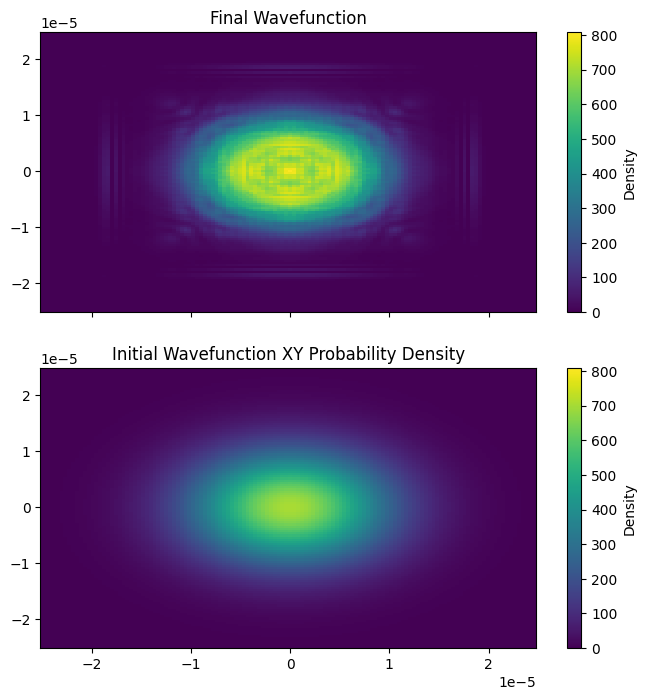

In [8]:
initial_xy_density = np.sum(np.abs(init_psi)**2 * GPE1.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*GPE1.l**(3/2))**2 * GPE1.dx/GPE1.l, axis=2)

uxy_density = np.sum(np.abs(wf)**2 * GPE1.dx/GPE1.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * GPE1.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX, pY, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX, pY, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")


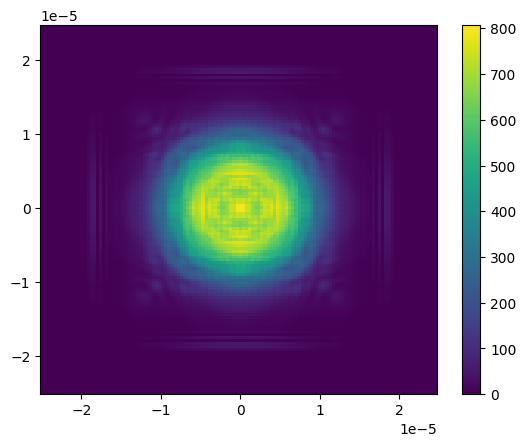

In [10]:
plt.pcolormesh(pX, pY, uxy_density)
plt.colorbar()

2.20454076850486e-06
2.4299590919324807e-05
2.0472345624443875
[np.float64(4.889627589458944e-05), np.float64(514.5261649240322), np.float64(6.23296450586476e-05)]


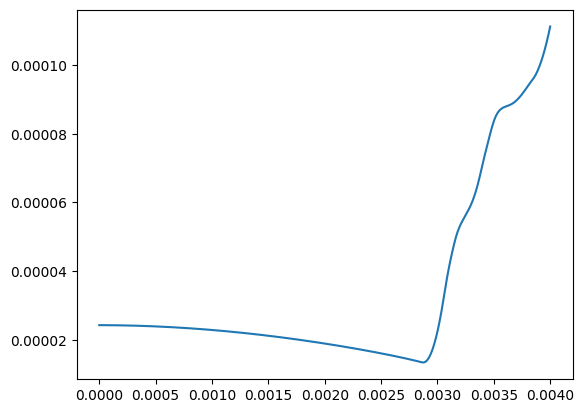

In [163]:
kap = GPE1.sigma/GPE1.l
om = GPE1.omega
omM = GPE1.omega * np.sqrt(5-np.power(kap, -4))
plt.plot(times, waist)
amp = (np.max(waist) - np.min(waist))*0.5
base = (np.max(waist) + np.min(waist))*0.5


print(GPE1.sigma * np.sqrt(3/2))
print(waist[0])
print(omM/GPE1.omega)

print([amp, omM, base])

2.20454076850486e-06
2.4299795722353408e-05
2.0472345624443875
[4.79531489e-06 4.87687935e+02 1.94957675e-05]
[np.float64(3.2939387960367642e-06), np.float64(514.5261649240322), np.float64(2.1005856926316642e-05)]
0.9486657824972659


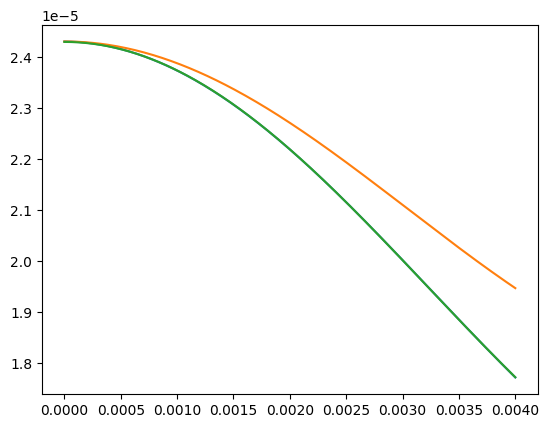

In [44]:
kap = GPE1.sigma/GPE1.l
om = GPE1.omega
omM = GPE1.omega * np.sqrt(5-np.power(kap, -4))
plt.plot(times, waist)
amp = (np.max(waist) - np.min(waist))*0.5
base = (np.max(waist) + np.min(waist))*0.5
plt.plot(times, amp*np.cos(omM * times)+base)

print(GPE1.sigma * np.sqrt(3/2))
print(waist[0])
print(omM/GPE1.omega)

def func(x,a,b,c):
    return a*np.cos(b*x)+c



from scipy.optimize import curve_fit

popt, covt = curve_fit(func, times, waist, p0=[amp, omM, base])

plt.plot(times, func(times, *popt))
print(popt)
print([amp, omM, base])

b = popt[1]
print((5-(b/om)**2)**(-1/4))

time scale: 0.0039788735772973835
unitless time:  0.25132741228718347
unitless distance: 19.332011073400107
time resolution: 2.5132741228718343e-05
space resolution: 0.15103133651093853
Psi normalization: 1.000000000000004
Final WF normalization 1.0000000000020661


'diff = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))\nim3 = ax3.pcolormesh(pX, pY, diff)\nax3.set_title("Absolute Error")\nfig.colorbar(im3, ax=ax3, label="Error")\n\nglobal_rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(np.max(initial_xy_density))\nim4 = ax4.pcolormesh(pX, pY, global_rel_error)\nax4.set_title("Global Relative Error")\nfig.colorbar(im4, ax=ax4, label="Error")\n\nrel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)\nim5 = ax5.pcolormesh(pX, pY, rel_error)\nax5.set_title("Relative Error")\nfig.colorbar(im5, ax=ax5, label="Error")\n\nprint("Max Global Relative Error:", np.max(global_rel_error))\nprint("Boundary error:",rel_error[-1,-1])\n\n# L2 norm error (more standard)\nL2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * GPE1.dx**3)\nprint("L2 Error:", L2_error)\n\nslice = 50\nsliced_L2_error = np.sqrt(np.sum((np.abs(final_wf[slice:-1*slice]) - np.abs(init_psi[slice:-1*slice]))*

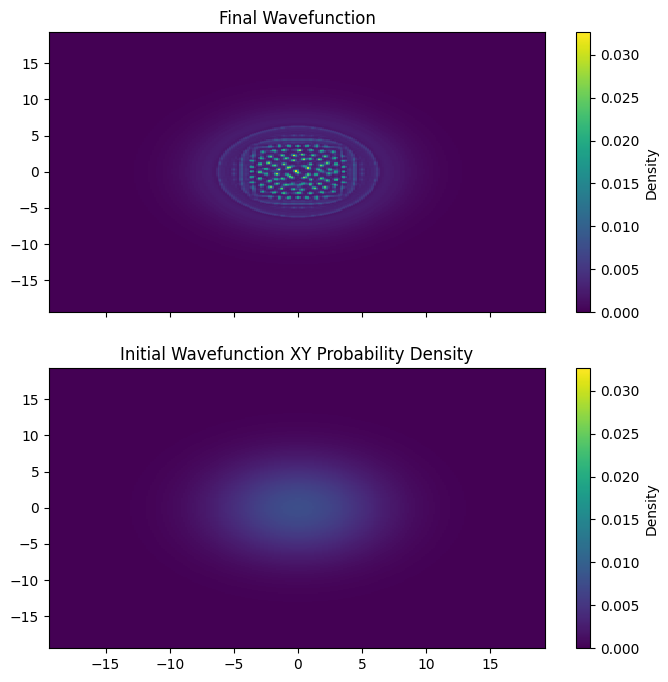

In [ ]:
# Define simulation parameters

@dataclass
class GPE:

    debug = False
    
    Np=5e6
    m = 1.44e-25  #kg
    omega = 2 * pi * 40 #Hz
    a0 = 5.29e-9 #m
    g0 = 4*pi*hbar**2*a0* Np/m
    gamma = 1

    a02 = 2e-22

    g2 = 6*np.sqrt(5) * hbar**2 * a02 * Np / m

    sigma = 11e-6

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale

    G0 = g0/(l**3*hbar*omega)
    G2 = g2/(hbar*omega*l**5)

    #sim params

    up = 2.5 * sigma
    N = 256

    cutoff = False
    k_cutoff = 1e6 #m^-1
    
    ev_time = 1e-3 #s
    time_steps = 10000

    x = np.linspace(-up,up,N, endpoint=False)
    dx = x[1]-x[0]

    X, Y, Z = np.meshgrid(x,x,x, indexing='ij')
    
def dprint(*args):
    if GPE.debug:
        print(*args)

# Define wavefunction: Gaussian ansatz TODO

def psi(x, y, z):
    sigma, dx = GPE.sigma, GPE.dx
    gaussian = np.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = np.sum(np.abs(gaussian)**2) * dx**3
    gaussian *= (1/norm)**(1/2) 
    return gaussian

def initialize():

    N = GPE.N
    X, Y, Z = GPE.X, GPE.Y, GPE.Z
    dx = GPE.dx
    l = GPE.l

    assert dx < l

    wf = psi(X, Y, Z)
    print("Psi normalization:", np.sum((np.absolute(wf)**2) * dx**3))

    #Nondimensionalization
    unitless_wf = wf * l**(3/2)

    #uX stands for unitless X coordinates
    uX, uY, uZ = X/l, Y/l, Z/l

    # Define momentum grid
    k = 2*pi*np.fft.fftfreq(N, d=dx/l)
    KX, KY, KZ = np.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    return unitless_wf, (uX, uY, uZ), (KX, KY, KZ)

# Define operators

def trap_potential(x,y,z):
    gam = GPE.gamma
    return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def g0_term(psi): # in position basis
    return GPE.G0 * np.abs(psi)**2


def kinetic_energy(kx, ky, kz):
    return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

def quadrupole_term(psi, kx,ky,kz):

    psi_mag_fft = np.fft.fftn(np.abs(psi)**2)
    op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

    if GPE.cutoff:
        
        k2 = kx**2+ky**2+kz**2
        unitless_k = (GPE.k_cutoff * GPE.l)**2

        rho2 = kx**2+ky**2
        mask = (k2 < (GPE.k_cutoff*GPE.l)**2)
        #mask = (rho2 < unitless_k) & (kz**2 < unitless_k)
        #mask = (k2 < np.max(k2)*(1/100)) 

        op *=mask

        op = GPE.G2 * np.real(np.fft.ifftn(op))

        return op
    else:

        return GPE.G2 * np.real(np.fft.ifftn(op))

def evolution():

    ev_time = GPE.ev_time
    time_steps = GPE.time_steps

    dxu = GPE.dx/GPE.l
    
    dt = ev_time/time_steps
    dtau = dt/GPE.tau # unitless time step

    print("time scale:", GPE.tau)
    print("unitless time: ", ev_time/GPE.tau)
    print("unitless distance:", GPE.up/GPE.l)
    print("time resolution:", dtau)
    print("space resolution:", dxu)

    wf, (uX,uY,uZ), (KX,KY,KZ) = initialize()

    potential_step = np.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = np.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    waist = []

    for _ in range(time_steps):

        # Apply position-basis operators for interval dt/2

        q1 = quadrupole_term(wf, KX,KY,KZ)
        
        wf *= potential_step
        wf *= np.exp(-1j *(g0_term(wf) + q1) * (dtau/2))

        # Apply momentum-basis operators for interval dt

        wf = np.fft.fftn(wf)
        
        wf *= KE_step

        wf = np.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        q2 = quadrupole_term(wf, KX,KY,KZ)

        wf *= potential_step
        wf *= np.exp(-1j*(g0_term(wf) + q2) * (dtau/2))

        

        #waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3)
        
    #waist = np.array(waist) * GPE.l**2
    
    # Redimensionalize result

    redim_wf = wf* GPE.l**(-3/2)

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE.dx**3)

    return redim_wf, wf, waist
    
final_wf, wf, waist = evolution()

ev_time = GPE.ev_time
time_steps = GPE.time_steps
times = np.linspace(0, ev_time, time_steps)

x = GPE.x
pX, pY = np.meshgrid(x, x, indexing='ij')

init_psi = psi(GPE.X, GPE.Y, GPE.Z)
initial_xy_density = np.sum(np.abs(init_psi)**2 * GPE.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*GPE.l**(3/2))**2 * GPE.dx/GPE.l, axis=2)

uxy_density = np.sum(np.abs(wf)**2 * GPE.dx/GPE.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * GPE.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX/GPE.l, pY/GPE.l, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX/GPE.l, pY/GPE.l, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

'''diff = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))
im3 = ax3.pcolormesh(pX, pY, diff)
ax3.set_title("Absolute Error")
fig.colorbar(im3, ax=ax3, label="Error")

global_rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(np.max(initial_xy_density))
im4 = ax4.pcolormesh(pX, pY, global_rel_error)
ax4.set_title("Global Relative Error")
fig.colorbar(im4, ax=ax4, label="Error")

rel_error = np.abs(np.abs(xy_density)-np.abs(initial_xy_density))/np.abs(initial_xy_density)
im5 = ax5.pcolormesh(pX, pY, rel_error)
ax5.set_title("Relative Error")
fig.colorbar(im5, ax=ax5, label="Error")

print("Max Global Relative Error:", np.max(global_rel_error))
print("Boundary error:",rel_error[-1,-1])

# L2 norm error (more standard)
L2_error = np.sqrt(np.sum((np.abs(final_wf) - np.abs(init_psi))**2) * GPE1.dx**3)
print("L2 Error:", L2_error)

slice = 50
sliced_L2_error = np.sqrt(np.sum((np.abs(final_wf[slice:-1*slice]) - np.abs(init_psi[slice:-1*slice]))**2) * GPE1.dx**3)
print(f"(ONLY CONSIDER FOR STEADY STATE) Sliced L2 Error (First {slice} points):", sliced_L2_error)

# Or relative L2 error
rel_L2_error = L2_error / np.sqrt(np.sum(np.abs(init_psi)**2) * GPE1.dx**3)
print("Relative L2 Error:", rel_L2_error)'''

Text(0.5, 1.0, 'Final Wavefunction')

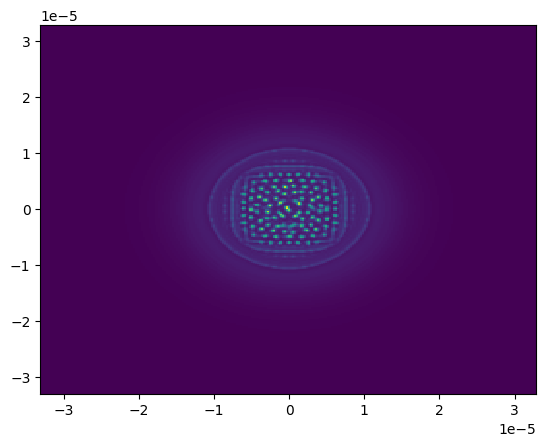

In [64]:
plt.pcolormesh(pX, pY, uxy_density)
ax1.set_title("Final Wavefunction")

Apple Silicon GPU (MPS) detected. Simulation will run on GPU.
time scale: 0.0039788735772973835
unitless time:  0.25132741228718347
unitless distance: 16.11000922783342
time resolution: 2.5132741228718343e-05
space resolution: 0.1258598726495363
Psi normalization: tensor(1.0000, device='mps:0')


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/_inductor/lowering.py:1890: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


Roughly 0.0% done
Roughly 10.0% done
Roughly 20.0% done
Roughly 30.0% done
Roughly 40.0% done
Roughly 50.0% done
Roughly 60.0% done
Roughly 70.0% done
Roughly 80.0% done
Roughly 90.0% done
Final WF normalization 0.9897375


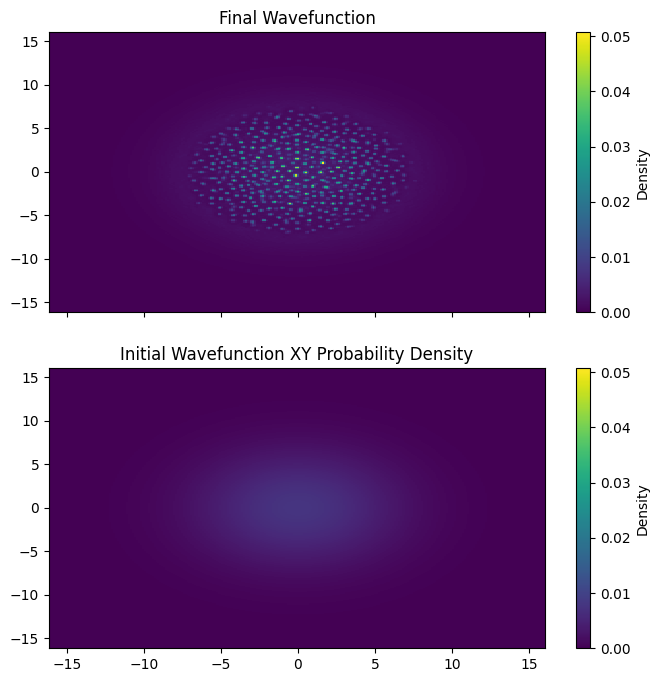

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon GPU (MPS) detected. Simulation will run on GPU.")
else:
    device = torch.device("cpu")
    print("MPS not available. Falling back to CPU.")

# Define simulation parameters

@dataclass
class GPE:

    debug = False

    high_precision = False

    if high_precision:
        complex_type = torch.complex128
        real_type = torch.float64

    else:
        complex_type = torch.complex64
        real_type = torch.float32
    



    Np=5e6
    m = 1.44e-25  #kg
    omega = 2 * pi * 40 #Hz
    a0 = 5.29e-9 #m
    g0 = 4*pi*hbar**2*a0* Np/m
    gamma = 1
    a02 = 2e-22
    g2 = 6*np.sqrt(5) * hbar**2 * a02 * Np / m
    sigma = 11e-6

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale
    G0 = g0/(l**3*hbar*omega)
    G2 = g2/(hbar*omega*l**5)

    waist = False
    cutoff = False
    k_cutoff = pi/(2.5e-6) #m^-1

    #sim params

    up = 2.5 * sigma
    N = 256

    ev_time = 1e-3 #s
    time_steps = 10000

    x = torch.linspace(-up,up,N+1, device=device, dtype=real_type)[:-1] # avoid double counting endpoint 
    dx = (x[1]-x[0]).item()

    X, Y, Z = torch.meshgrid(x,x,x, indexing='ij')
    
def dprint(*args):
    if GPE.debug:
        print(*args)

# Define wavefunction: Gaussian ansatz TODO

def psi(x, y, z):
    sigma, dx = GPE.sigma, GPE.dx
    gaussian = torch.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).to(GPE.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = torch.sum(torch.abs(gaussian)**2) * dx**3
    gaussian *= (1/norm)**(1/2) 
    return gaussian


# Define operators

def trap_potential(x,y,z):
    gam = GPE.gamma
    return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def g0_term(psi): # in position basis
    return GPE.G0 * torch.abs(psi)**2


def kinetic_energy(kx, ky, kz):
    return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

def quadrupole_term(psi, kx,ky,kz):

    psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
    op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

    if GPE.cutoff:
        
        k2 = kx**2+ky**2+kz**2
        unitless_k = (GPE.k_cutoff * GPE.l)**2

        rho2 = kx**2+ky**2
        #mask = (k2 < (GPE.k_cutoff*GPE.l)**2)
        mask = (rho2 < unitless_k) & (kz**2 < unitless_k)

        op *=mask

        op = GPE.G2 * torch.real(torch.fft.ifftn(op))

        return op
    else:

        return GPE.G2 * torch.real(torch.fft.ifftn(op))
    
def wf_cutoff(wf, kx, ky, kz):

    assert GPE.cutoff == False, "Make sure potential cutoff is disabled if using wf_cutoff function"

    k2 = kx**2+ky**2+kz**2
    unitless_kc = (GPE.k_cutoff * GPE.l)

    mask = (k2 < unitless_kc**2)

    wf *= mask
    
    return wf

@torch.compile
def single_loop(wf, kx, ky, kz, potential_step, KE_step, dtau):

    
        
    wf *= potential_step
    q1 = quadrupole_term(wf, kx,ky,kz)
    wf *= torch.exp(-1j *(g0_term(wf) + q1) * (dtau/2))

    # Apply momentum-basis operators for interval dt

    wf = torch.fft.fftn(wf)
    
    wf *= KE_step
    # wf = wf_cutoff(wf, kx, ky, kz)

    wf = torch.fft.ifftn(wf)

    # Apply position-basis operators for interval dt/2

    

    wf *= potential_step
    q2 = quadrupole_term(wf, kx,ky,kz)
    wf *= torch.exp(-1j*(g0_term(wf) + q2) * (dtau/2))

    return wf

def evolution():

    ev_time = GPE.ev_time
    time_steps = GPE.time_steps

    dxu = GPE.dx/GPE.l
    
    dt = ev_time/time_steps
    dtau = dt/GPE.tau # unitless time step
    

    print("time scale:", GPE.tau)
    print("unitless time: ", ev_time/GPE.tau)
    print("unitless distance:", GPE.up/GPE.l)
    print("time resolution:", dtau)
    print("space resolution:", dxu)

    N = GPE.N
    X, Y, Z = GPE.X, GPE.Y, GPE.Z
    dx = GPE.dx
    l = GPE.l

    assert dx < l

    wf = psi(X, Y, Z)
    print("Psi normalization:", torch.sum(torch.abs(wf)**2 * dx**3))

    #Nondimensionalization
    wf = (wf * l**(3/2)).to(GPE.complex_type)

    #uX stands for unitless X coordinates
    uX, uY, uZ = X/l, Y/l, Z/l

    # Define momentum grid
    k = 2*pi*torch.fft.fftfreq(N, d=dx/l, device=device, dtype=GPE.real_type)
    KX, KY, KZ = torch.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z

    potential_step = torch.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = torch.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    waist = []; uR2 = uX**2+uY**2+uZ**2

    for i in range(time_steps):

        wf = single_loop(wf, KX, KY, KZ, potential_step, KE_step, dtau)

        if i % (time_steps//10) == 0: print("Roughly {}% done".format(i/time_steps*100))

        if GPE.waist: waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3) 
        
    waist = np.array(waist) * GPE.l**2
    
    # Redimensionalize result

    redim_wf = wf* GPE.l**(-3/2)

    redim_wf = redim_wf.cpu().numpy()
    wf = wf.cpu().numpy()

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE.dx**3)

    return redim_wf, wf, waist
    
final_wf, wf, waist = evolution()

ev_time = GPE.ev_time
time_steps = GPE.time_steps
times = np.linspace(0, ev_time, time_steps)

x = GPE.x.cpu().numpy()
pX, pY = np.meshgrid(x, x, indexing='ij')

init_psi = psi(GPE.X, GPE.Y, GPE.Z).cpu().numpy()
initial_xy_density = np.sum(np.abs(init_psi)**2 * GPE.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*GPE.l**(3/2))**2 * GPE.dx/GPE.l, axis=2)

uxy_density = np.sum(np.abs(wf)**2 * GPE.dx/GPE.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * GPE.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX/GPE.l, pY/GPE.l, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX/GPE.l, pY/GPE.l, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

Text(0.5, 1.0, 'Final wavefunction slice at x=0')

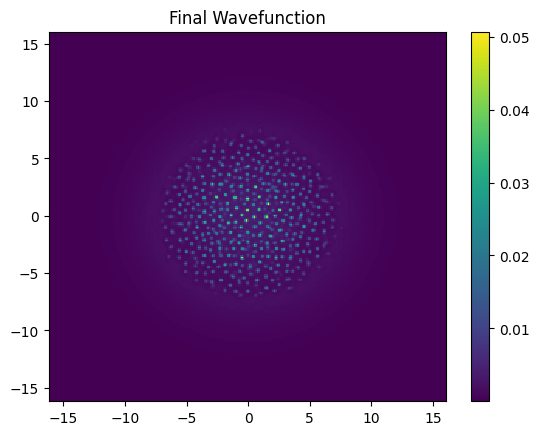

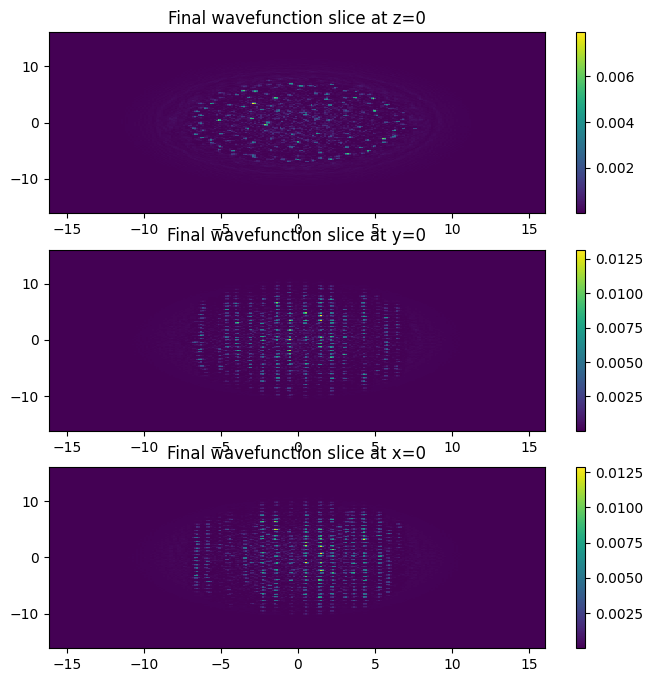

In [5]:
plt.pcolormesh(pX/GPE.l, pY/GPE.l, uxy_density)
plt.colorbar()
plt.title("Final Wavefunction")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

im1 = ax1.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[:,:,len(wf)//2])**2)
fig.colorbar(im1, ax=ax1)
ax1.set_title("Final wavefunction slice at z=0")

im2 = ax2.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[:,len(wf)//2,:])**2)
fig.colorbar(im2, ax=ax2)
ax2.set_title("Final wavefunction slice at y=0")

im3 = ax3.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[len(wf)//2,:,:])**2)
fig.colorbar(im3, ax=ax3)
ax3.set_title("Final wavefunction slice at x=0")


In [3]:
omega = 2 * pi * 40 #Hz
m = 1.44e-25 #kg
a0 = -4e-13 #m
g0 = 4*pi*hbar**2*a0/m
time_steps = 100
dt = 2e-3/time_steps

l = np.sqrt(hbar/(m * omega)) #length scale
up = 4*l
N = 100
x = np.linspace(-up,up,N)
dx = x[1]-x[0]
X, Y, Z = np.meshgrid(x,x,x, indexing='ij')

def psi(x, y, z, dx):
    Np=5e6
    sigma = 1.8e-6
    gaussian = np.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = np.sum(np.abs(gaussian)**2) * dx**3
    gaussian *= (Np/norm)**(1/2) 
    return gaussian





{'grid': <pygpe.shared.grid.Grid object at 0x12ce90260>, 'component': array([[[165.85431167+0.j, 221.15690761+0.j, 293.17286189+0.j, ...,
         293.17286189+0.j, 221.15690761+0.j, 165.85431167+0.j],
        [221.15690761+0.j, 294.89964589+0.j, 390.92865826+0.j, ...,
         390.92865826+0.j, 294.89964589+0.j, 221.15690761+0.j],
        [293.17286189+0.j, 390.92865826+0.j, 518.22787168+0.j, ...,
         518.22787168+0.j, 390.92865826+0.j, 293.17286189+0.j],
        ...,
        [293.17286189+0.j, 390.92865826+0.j, 518.22787168+0.j, ...,
         518.22787168+0.j, 390.92865826+0.j, 293.17286189+0.j],
        [221.15690761+0.j, 294.89964589+0.j, 390.92865826+0.j, ...,
         390.92865826+0.j, 294.89964589+0.j, 221.15690761+0.j],
        [165.85431167+0.j, 221.15690761+0.j, 293.17286189+0.j, ...,
         293.17286189+0.j, 221.15690761+0.j, 165.85431167+0.j]],

       [[221.15690761+0.j, 294.89964589+0.j, 390.92865826+0.j, ...,
         390.92865826+0.j, 294.89964589+0.j, 221.156907

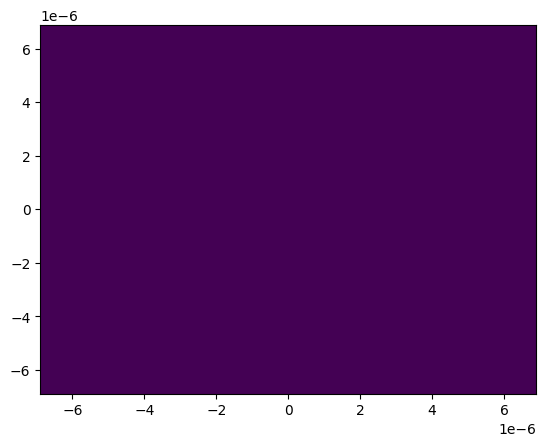

In [24]:
import pygpe
import pygpe.scalar as gpe

def psi(x, y, z, dx):
    Np=5e6
    sigma = 1.8e-6
    gaussian = np.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).astype(np.complex128) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = np.sum(np.abs(gaussian)**2) * dx**3
    gaussian *= (Np/norm)**(1/2) 
    return gaussian


N = 100
omega = 2 * pi * 40 #Hz
m = 1.44e-25 #kg
a0 = -4e-13 #m
g0 = 4*pi*hbar**2*a0/m
time_steps = 100
dt = 2e-3/time_steps

l = np.sqrt(hbar/(m * omega)) #length scale
up = 4*l
x = np.linspace(-up,up,N)
dx = x[1]-x[0]

X, Y, Z = np.meshgrid(x,x,x, indexing='ij')
pX, pY = np.meshgrid(x, x, indexing='ij')

gridpoints = (N,N,N)
gridspacing = (dx, dx,dx)

grid = gpe.Grid(gridpoints, gridspacing)

params = {
    "g": g0,
    "trap": 1,
    "nt":time_steps,
    "dt":dt,
    "t":0
}

wavefunction = gpe.ScalarWavefunction(grid)
wavefunction.set_wavefunction(psi(X,Y,Z, dx))

print(vars(wavefunction))
print(np.mean(wavefunction.component))

for i in range(params['nt']):
    gpe.step_wavefunction(wavefunction, params)
    print(np.mean(wavefunction.component))


new_xy_density = np.sum(np.abs(wavefunction.component)**2 * dx, axis=2)


plt.pcolormesh(pX,pY,new_xy_density)

